<a href="https://colab.research.google.com/github/goija/vortexarcheologie_v72/blob/main/ELSmapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

In [3]:
X = 7   # columns
Y = 13  # rows
N = X * Y

grid = np.arange(1, N+1).reshape(Y, X)  # row-major: 1..7 top row, etc.
grid


array([[ 1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19, 20, 21],
       [22, 23, 24, 25, 26, 27, 28],
       [29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42],
       [43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56],
       [57, 58, 59, 60, 61, 62, 63],
       [64, 65, 66, 67, 68, 69, 70],
       [71, 72, 73, 74, 75, 76, 77],
       [78, 79, 80, 81, 82, 83, 84],
       [85, 86, 87, 88, 89, 90, 91]])

In [4]:
def idx_to_rc(i, X):
    """1-based index -> (row, col) 0-based."""
    i0 = i - 1
    return i0 // X, i0 % X

def rc_to_idx(r, c, X):
    """(row, col) 0-based -> 1-based index."""
    return r * X + c + 1


In [5]:
def els_linear(start, D, N):
    """
    ELS as linear trajectory in 1..N:
    start, start+D, start+2D, ... while <= N
    """
    seq = []
    k = 0
    while True:
        v = start + k * D
        if v < 1 or v > N:
            break
        seq.append(v)
        k += 1
    return seq

# Jouw voorbeelden
seq_D7 = els_linear(1, 7, N)
seq_D8 = els_linear(1, 8, N)
seq_D6 = els_linear(7, 6, N)

seq_D7, seq_D8, seq_D6[:10], len(seq_D6)


([1, 8, 15, 22, 29, 36, 43, 50, 57, 64, 71, 78, 85],
 [1, 9, 17, 25, 33, 41, 49, 57, 65, 73, 81, 89],
 [7, 13, 19, 25, 31, 37, 43, 49, 55, 61],
 15)

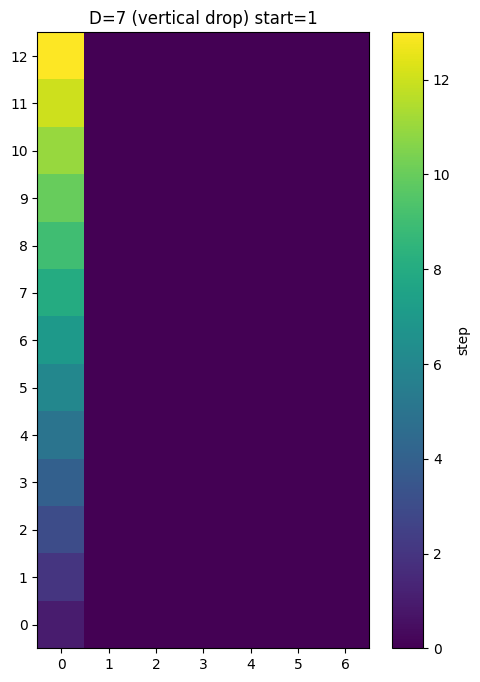

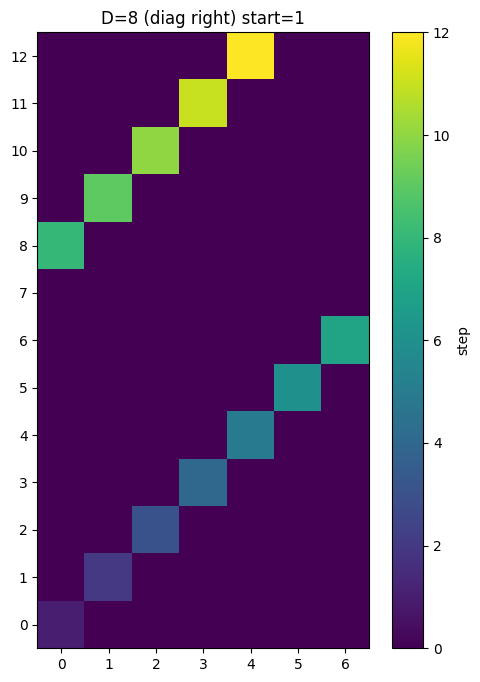

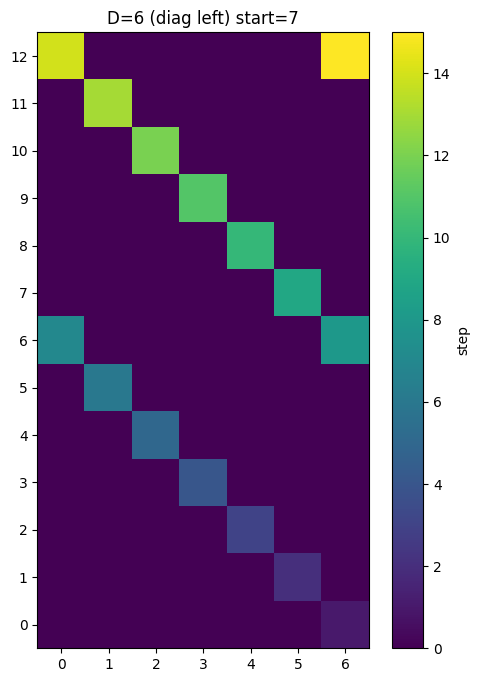

In [6]:
def plot_path(seq, X, Y, title="ELS path"):
    img = np.zeros((Y, X), dtype=float)

    for t, i in enumerate(seq):
        r, c = idx_to_rc(i, X)
        img[r, c] = t + 1  # step number

    plt.figure(figsize=(6, 8))
    plt.imshow(img, cmap="viridis", interpolation="nearest")
    plt.colorbar(label="step")
    plt.title(title)
    plt.xticks(range(X))
    plt.yticks(range(Y))
    plt.gca().invert_yaxis()  # top row as row 0 visually
    plt.show()

plot_path(seq_D7, X, Y, "D=7 (vertical drop) start=1")
plot_path(seq_D8, X, Y, "D=8 (diag right) start=1")
plot_path(seq_D6, X, Y, "D=6 (diag left) start=7")


In [12]:
BASE_F0 = 110.0

def path_to_semitones(seq, X):
    """
    Convert step-to-step movement to semitone offsets.
    Rule (simple + deterministic):
      dr, dc computed from grid positions:
      semitone = 2*dc + 3*dr
    """
    semis = [0]
    for a, b in zip(seq, seq[1:]):
        ra, ca = idx_to_rc(a, X)
        rb, cb = idx_to_rc(b, X)
        dr = rb - ra
        dc = cb - ca
        semis.append(semis[-1] + (2*dc + 3*dr))
    return semis

def semitones_to_freqs(semis, f0=BASE_F0):
    return [f0 * (2 ** (s/12)) for s in semis]

semis7 = path_to_semitones(seq_D7, X)
freqs7 = semitones_to_freqs(semis7)

semis8 = path_to_semitones(seq_D8, X)
freqs8 = semitones_to_freqs(semis8)

semis6 = path_to_semitones(seq_D6, X)
freqs6 = semitones_to_freqs(semis6)

freqs7[:5], freqs8[:5], freqs6[:5]


([110.0, 130.8127826502993, 155.56349186104046, 184.9972113558172, 220.0],
 [110.0,
  146.8323839587038,
  195.99771799087463,
  261.6255653005986,
  349.2282314330039],
 [110.0,
  116.54094037952248,
  123.47082531403103,
  130.8127826502993,
  138.59131548843604])

In [13]:
# https://colab.research.google.com/github/<USER>/<REPO>/blob/main/notebooks/ELS_Vortex_91.ipynb

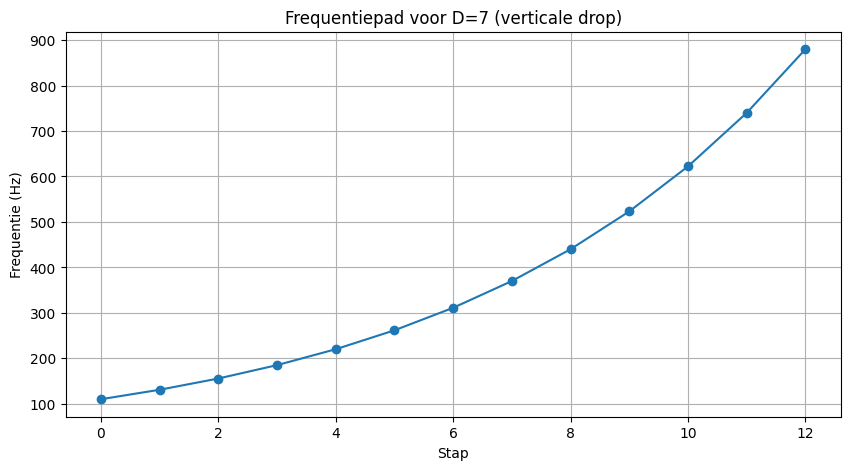

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(freqs7, marker='o')
plt.title('Frequentiepad voor D=7 (verticale drop)')
plt.xlabel('Stap')
plt.ylabel('Frequentie (Hz)')
plt.grid(True)
plt.show()

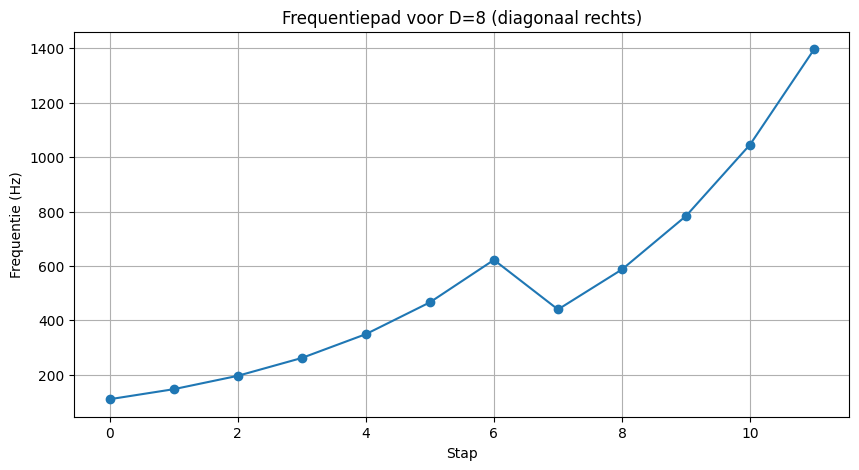

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(freqs8, marker='o')
plt.title('Frequentiepad voor D=8 (diagonaal rechts)')
plt.xlabel('Stap')
plt.ylabel('Frequentie (Hz)')
plt.grid(True)
plt.show()

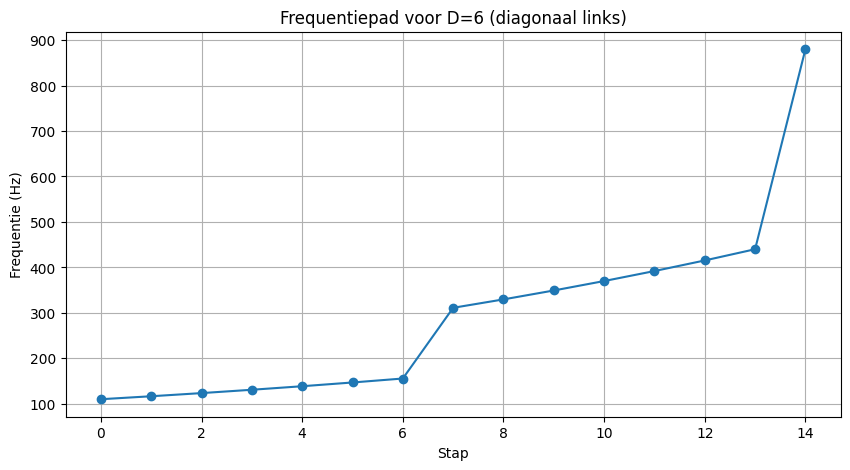

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(freqs6, marker='o')
plt.title('Frequentiepad voor D=6 (diagonaal links)')
plt.xlabel('Stap')
plt.ylabel('Frequentie (Hz)')
plt.grid(True)
plt.show()